In [1]:
import sys
sys.path.append('../')

import numpy as np
from matplotlib import pyplot as plt
from qutip.qip.operations import rz, cz_gate
from tqdm import tqdm
from matplotlib.colors import LogNorm
import pytz, cmath, itertools
import scqubits.settings as settings
settings.OVERLAP_THRESHOLD = 0.3
from joblib import Parallel, delayed
import scipy.sparse as ssp
from sympy import symbols
import utils_2Q_gate_zp as ut
import pandas as pd
import scipy as sp
from multiprocessing import Pool
import qutip as qt
import multiprocessing as mp
from multiprocessing import Pool
import scqubits as scq
from sympy import symbols
import scipy.sparse as ssp
from scipy.ndimage import gaussian_filter
from datetime import datetime

In [4]:
cz = pd.read_csv('data/data_cz_3ncut_truc1=300_select.txt')
x0_vec = cz[['tg', 'drive_amp', 'detune']].to_numpy()#[[2, 9, -1],:]

for i in x0_vec:
    print(np.round(i,6).tolist(),',')

[20.047153, 0.019435, 0.007273] ,
[26.101697, 0.045995, 0.027267] ,
[32.046892, 0.040078, 0.029708] ,
[38.041642, 0.033338, 0.030435] ,
[44.030707, 0.027548, 0.028865] ,
[50.072552, 0.023108, 0.026995] ,
[56.09293, 0.03395, 0.026046] ,
[62.05406, 0.030092, 0.026695] ,
[68.038002, 0.026412, 0.026634] ,
[74.046742, 0.023287, 0.026334] ,
[80.075366, 0.020755, 0.026011] ,
[86.098006, 0.018598, 0.025596] ,
[91.94156, 0.016951, 0.02508] ,
[97.927037, 0.015593, 0.023897] ,
[104.0629, 0.014504, 0.021787] ,
[110.014433, 0.01363, 0.020714] ,
[116.087948, 0.012801, 0.020071] ,
[121.917538, 0.012092, 0.019415] ,
[127.982544, 0.011424, 0.018543] ,
[134.045327, 0.010845, 0.017713] ,
[140.019538, 0.01031, 0.01705] ,
[146.02026, 0.009837, 0.016406] ,
[151.989666, 0.009403, 0.015775] ,
[158.042842, 0.008999, 0.015168] ,
[164.010081, 0.008634, 0.014647] ,
[170.026627, 0.008296, 0.01413] ,
[175.990284, 0.007985, 0.01366] ,
[182.000383, 0.007692, 0.013213] ,
[187.99595, 0.007421, 0.0128] ,
[194.002917, 0.

In [ ]:
[tg,drive_amp,detune,f_300_200_True,f_300_1000_True] = [116.087948,0.012801,0.020071,-3.07740722,-3.08067203]
# [200.001076,0.006936,0.012052,-3.94183644,-3.90319705]
truc1, truc_tot, charge_pick = 300, 1000, False
truc_full = 200
num_cpus = 16
folder = f'../../data/3ncut_two_zeropi/truc1={truc1}_truc2={truc_tot}_pick={charge_pick}/'
hspace_full = pd.read_csv(folder+ 'hspace_full.txt').to_numpy().flatten().tolist()
eval_tot = 2*np.pi* pd.read_csv(folder+ 'eval_tot.txt').to_numpy().flatten()
n_theta1_dress = 2*np.pi* pd.read_csv(folder+ 'n_theta1_dress.txt').map(complex).to_numpy()
eval_tot = eval_tot[:truc_full]
hspace_full = hspace_full[:truc_full]
n_theta1_dress = qt.Qobj(n_theta1_dress[np.ix_(np.arange(truc_full), np.arange(truc_full))])

logi_state_one = [0,2]
logi_state = ['0-0', '0-2', '2-0', '2-2']
W_20_50 = eval_tot[hspace_full.index('5-0')] - eval_tot[hspace_full.index('2-0')]
H0 = qt.Qobj(np.diag(eval_tot))
logi_idx = [hspace_full.index(i) for i in logi_state]
H_qbt_drive = [H0, [n_theta1_dress, ut.drive_gauss_A] ]
pulse_args = {'drive_amp_A': drive_amp,
            'drive_freq_A': W_20_50 + 2*np.pi*detune,
            'gate_time': tg}
tlist = np.linspace(0, tg, num=1*int(tg))  # total time
state_tot = [qt.basis(truc_full, i) for i in range(truc_full)]
state_interest = ['0-1', '1-0', '1-1',
                    '0-5', '1-2', '1-5',
                    '5-0', '2-1', '5-1',
                    '2-5', '5-2', '5-5']

In [ ]:
c_op_list = []
args_indep = [tg, drive_amp, detune]
args = [H_qbt_drive, W_20_50, num_cpus, c_op_list, logi_idx ]
f_ideal = ut.cz_fidelity_log_noise(args_indep, *args)
print(f'f_ideal (dim={truc_full})=', f_ideal)

In [ ]:
result = {}
for idx, state_i in enumerate(logi_state_one):
    for jdx, state_j in tqdm(enumerate(logi_state_one)):
        # This simulation is just for viewing the affect of the pulse
        result[idx, jdx] = qt.mesolve(
            H_qbt_drive,
            qt.basis(truc_full, hspace_full.index( str(state_i) +'-'+str(state_j) )),
            tlist,
            e_ops=[state * state.dag() for state in state_tot],
            args=pulse_args,
            options=qt.Options(store_states=True)  )


0it [00:00, ?it/s]

2it [00:07,  3.58s/it]
2it [00:07,  3.92s/it]


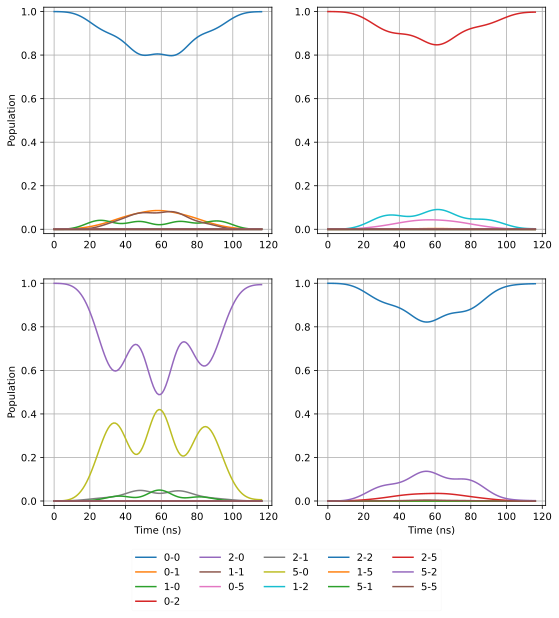

In [ ]:
fig, ax = plt.subplots(figsize=(9,9), nrows=2, ncols=2)
for idx, state in enumerate(logi_state_one):
    for jdx, state in enumerate(logi_state_one):
        for kdx, res in zip(hspace_full, result[idx,jdx].expect):
            if kdx in logi_state + state_interest:
                ax[idx][jdx].plot(tlist, gaussian_filter( np.array(res).flatten(), 3) ,  label=r"%s" %kdx)
        ax[idx][jdx].set_ylim(-0.02,1.02)
        ax[idx][jdx].grid()
    ax[1][idx].set_xlabel('Time (ns)')
    ax[idx][0].set_ylabel('Population')
handles, labels = ax[1][1].get_legend_handles_labels()
fig.legend(handles,labels, ncol=5,
            loc='upper center', bbox_to_anchor=(0.5, 0.05)).get_frame().set_alpha(0.1)

In [ ]:
fig, ax = plt.subplots(figsize=(10,10), nrows=2, ncols=2)
order = ['(a)', '(b)','(c)','(d)']
for idx, state_i in enumerate(logi_state_one):
    for jdx, state_j in enumerate(logi_state_one):
        for kdx, res in zip(hspace_full, result[idx,jdx].expect):
            ax[idx][jdx].plot(tlist, gaussian_filter( np.array(res).flatten(), 3) ,  label=r"%s" %kdx)
        ax[idx][jdx].set_ylim(-0.02,1.02)
        ax[idx][jdx].grid()
    ax[1][idx].set_xlabel('Time (ns)')
    ax[idx][0].set_ylabel('Population')
handles, labels = ax[1][1].get_legend_handles_labels()
fig.legend(handles,labels, ncol=5,
            loc='upper center', bbox_to_anchor=(0.5, 0.05)).get_frame().set_alpha(0.1)

### save data

In [19]:
pop = np.array(result[0,0].expect)
print(np.shape(pop))
pop_integral = pop.sum(axis=1)
print(np.shape(pop_integral))

ut.top_population(np.array(result[0,0].expect).sum(axis=1), hspace_full)
ut.top_population(np.array(result[0,1].expect).sum(axis=1), hspace_full)
ut.top_population(np.array(result[1,0].expect).sum(axis=1), hspace_full)
ut.top_population(np.array(result[1,1].expect).sum(axis=1), hspace_full)

(300, 1160)
(300,)

Top 10 values: [1052.0305085771124, 41.03521864630707, 32.54862928785607, 29.502797348919508, 2.889842755849889, 0.8968863003811121, 0.6468617635316523, 0.2896236325847128, 0.0762407354243564, 0.05166470644074631]
State of large population: ['0-0' '0-1' '1-1' '1-0' '4-1' '4-0' '0-4' '1-4' '4-4' '8-0']

Top 10 values: [1080.9023909952457, 53.15309717908457, 20.404851797189032, 4.090403051476735, 1.1182977172560626, 0.11682640347918989, 0.06381331086302226, 0.040346663188821644, 0.017368938302795747, 0.01570696983737373]
State of large population: ['0-2' '1-2' '0-5' '4-2' '1-5' '4-5' '0-9' '1-12' '0-18' '8-2']

Top 10 values: [883.0448538689232, 231.5428630510148, 24.86751647979443, 18.21103784306363, 0.9106040871470202, 0.8468971558152298, 0.43763451027698475, 0.10066016415435816, 0.0157236674558629, 0.007753572348463132]
State of large population: ['2-0' '5-0' '2-1' '5-1' '2-4' '9-0' '5-4' '9-1' '2-8' '1-2']

Top 10 values: [1064.8014126212354, 73.5729051870926, 18.

In [32]:
idx_00 = [hspace_full.index(i) for i in ['0-0', '0-1', '1-1', '1-0']]
idx_02 = [hspace_full.index(i) for i in ['0-2', '1-2', '0-5']]
idx_20 = [hspace_full.index(i) for i in ['2-0', '5-0', '2-1', '5-1']]
idx_22 = [hspace_full.index(i) for i in ['2-2', '5-2', '2-5']]

col_00 = ['tg'] + ['0-0', '0-1', '1-1', '1-0'] + ['other']
col_02 = ['tg'] + ['0-2', '1-2', '0-5'] + ['other']
col_20 = ['tg'] + ['2-0', '5-0', '2-1', '5-1'] + ['other']
col_22 = ['tg'] + ['2-2', '5-2', '2-5'] + ['other']

state_interest = idx_22
pop = np.array(result[1,1].expect)

pop_interest = pop[state_interest, :]
pop_other = np.delete(pop, state_interest, axis=0).sum(axis=0)
pop_save = np.vstack((tlist,pop_interest, pop_other)).T

df = pd.DataFrame(pop_save, columns=col_22)
# df.to_csv('data/cz_population_22_3ncut.txt', sep=',', index=False, header=True)

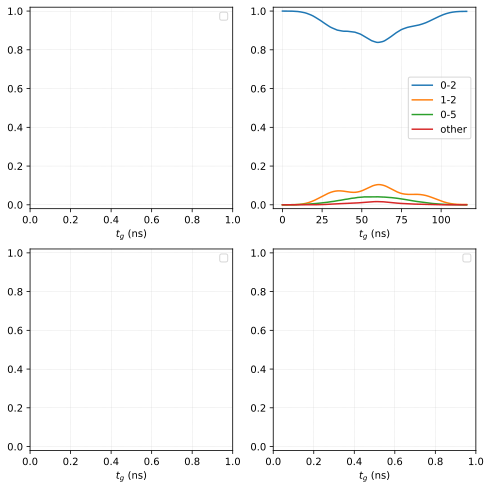

In [30]:
pop_02 = pd.read_csv('data/cz_population_02.txt').to_numpy()
x_size, y_size = 8, 8
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(x_size, y_size))
for i in np.arange(1, pop_02.shape[1]):
    ax[0][1].plot( pop_02[:,0], gaussian_filter( pop_02[:,i], 3), '-', label=col_02[i])
for i in range(2):
    for j in range(2):
        # ax[i].set_xlim(-25, 25)
        ax[i][j].set_ylim(-0.02, 1.02)
        ax[i][j].legend()
        ax[i][j].grid(linewidth=0.2, linestyle='--')
        ax[i][j].set_xlabel(r'$t_g$ (ns)')

#### cz_fidelity_sensivity

In [ ]:

detune_vec = np.linspace(-0.025, 0.025, 101)
values_grid = list(itertools.product(detuning + detune_vec, [drive_amp], [d_eta]))
fidelity_wd = Parallel(n_jobs=len(detune_vec), verbose=1)(delayed(ut.get_fidelity_cz_dark)(arg_de, *args)
                                            for arg_de in values_grid)

A_vec = np.linspace(-0.025, 0.025, 101)
values_grid = list(itertools.product([detuning], drive_amp+A_vec, [d_eta]))
fidelity_A = Parallel(n_jobs=len(A_vec), verbose=1)(delayed(ut.get_fidelity_cz_dark)(arg_de, *args)
                                            for arg_de in values_grid)

eta_vec = np.linspace(-0.05, 0.05, 101)
values_grid = list(itertools.product([detuning], [drive_amp], d_eta+eta_vec))
fidelity_eta = Parallel(n_jobs=len(eta_vec), verbose=1)(delayed(ut.get_fidelity_cz_dark)(arg_de, *args)
                                            for arg_de in values_grid)

[Parallel(n_jobs=101)]: Using backend LokyBackend with 101 concurrent workers.
[Parallel(n_jobs=101)]: Done   2 out of 101 | elapsed:    1.3s remaining:  1.0min
[Parallel(n_jobs=101)]: Done 101 out of 101 | elapsed:    1.9s finished
[Parallel(n_jobs=101)]: Using backend LokyBackend with 101 concurrent workers.
[Parallel(n_jobs=101)]: Done   2 out of 101 | elapsed:    1.2s remaining:  1.0min
[Parallel(n_jobs=101)]: Done 101 out of 101 | elapsed:    1.9s finished
[Parallel(n_jobs=101)]: Using backend LokyBackend with 101 concurrent workers.
[Parallel(n_jobs=101)]: Done   2 out of 101 | elapsed:    1.3s remaining:  1.0min
[Parallel(n_jobs=101)]: Done 101 out of 101 | elapsed:    2.1s finished


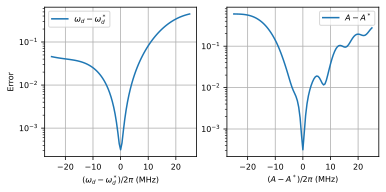

In [ ]:
error_vs_dwd = np.column_stack((np.round(10**3 * detune_vec, 2), np.round(fidelity_wd, 8)))
columns = ['dwd_vec(MHz)',  'error_wd']
df = pd.DataFrame(error_vs_dwd, columns=columns)
# df.to_csv('data/cz_dark_tg90_error_vs_dwd.txt', sep=',', index=True, header=True)

# error_vs_A = np.column_stack((np.round(10**3 * A_vec, 2), np.round(fidelity_A, 8)))
# columns = ['dA_vec(MHz)',  'error_A']
# df = pd.DataFrame(error_vs_A, columns=columns)
# df.to_csv('data/cz_dark_tg90_error_vs_dA.txt', sep=',', index=True, header=True)

# error_vs_eta = np.column_stack((np.round( eta_vec, 2), np.round(fidelity_eta, 8)))
# columns = ['eta_vec',  'error_A']
# df = pd.DataFrame(error_vs_eta, columns=columns)
# df.to_csv('data/cz_dark_tg90_error_vs_eta.txt', sep=',', index=True, header=True)

df_wd = pd.read_csv('data/cz_dark_tg90_error_vs_dwd.txt')
df_dA = pd.read_csv('data/cz_dark_tg90_error_vs_dA.txt')
df_eta = pd.read_csv('data/cz_dark_tg90_error_vs_eta.txt')

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(6,2.7))
ax[0].plot( df_wd['dwd_vec(MHz)'], 10**df_wd['error_wd'], '-', label='$\omega_{d} - \omega_{d}^*$')
ax[0].set_yscale('log')
ax[0].set_xlabel(r'$(\omega_{d} - \omega_{d}^*)/2\pi$ (MHz)')
ax[0].set_ylabel('Error')
ax[0].grid()
ax[0].legend()

ax[1].plot( df_dA['dA_vec(MHz)'], 10**df_dA['error_A'], '-', label='$A - A^*$')
ax[1].set_yscale('log')
ax[1].set_xlabel(r'$(A - A^*)/2\pi$ (MHz)')
ax[1].grid()
ax[1].legend()
# plt.savefig('cnot_fidelity_tg.png', dpi=300, bbox_inches='tight')